# XGBoost Classifier
**Data:** Temporally split parquets (`train_t03`, `val_t03`, `test_t03`)  
**Target:** `Results` → `1 = Fail`, `0 = Pass`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, balanced_accuracy_score,
    average_precision_score, brier_score_loss,
    RocCurveDisplay, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import joblib

sys.path.append(str(Path.cwd().parent))
from helpers.data_loader import DataLoader

## 2. Load Data

In [2]:
train = pd.read_parquet(DataLoader.transformed('train_t03.parquet'))
val   = pd.read_parquet(DataLoader.transformed('val_t03.parquet'))
test  = pd.read_parquet(DataLoader.transformed('test_t03.parquet'))

print(f'Train: {train.shape}  Val: {val.shape}  Test: {test.shape}')

Train: (109693, 17)  Val: (27483, 17)  Test: (34294, 17)


## 3. Prepare Features & Target

In [3]:
TARGET = 'Results'

X_train, y_train = train.drop(columns=TARGET), train[TARGET]
X_val,   y_val   = val.drop(columns=TARGET),   val[TARGET]
X_test,  y_test  = test.drop(columns=TARGET),  test[TARGET]

# scale_pos_weight for XGBoost = count(negative) / count(positive)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.4f}')

scale_pos_weight: 2.3869


## 4. Evaluate Function

In [4]:
def evaluate(model, X, y, split_name):
    y_pred       = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    cm           = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # --- derived rates ---
    fnr = fn / (fn + tp)
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    # --- metrics ---
    roc_auc       = roc_auc_score(y, y_pred_proba)
    pr_auc        = average_precision_score(y, y_pred_proba)
    brier         = brier_score_loss(y, y_pred_proba)
    mcc           = matthews_corrcoef(y, y_pred)
    bal_acc       = balanced_accuracy_score(y, y_pred)
    f1_fail       = f1_score(y, y_pred, pos_label=1, zero_division=0)
    f1_pass       = f1_score(y, y_pred, pos_label=0, zero_division=0)
    f1_weighted   = f1_score(y, y_pred, average='weighted', zero_division=0)
    prec_fail     = precision_score(y, y_pred, pos_label=1, zero_division=0)
    recall_fail   = recall_score(y, y_pred, pos_label=1, zero_division=0)

    print(f'=== {split_name} ===')
    print(classification_report(y, y_pred, target_names=['Pass', 'Fail']))

    print('── Key Rates ──')
    print(f'  Sensitivity (Recall Fail):           {tpr:.4f}')
    print(f'  Specificity (Recall Pass):           {tnr:.4f}')
    print(f'  False Negative Rate (missed fails):  {fnr:.4f}')
    print(f'  False Positive Rate (wasted insp.):  {fpr:.4f}')

    print('── Model Quality ──')
    print(f'  ROC-AUC:                             {roc_auc:.4f}')
    print(f'  PR-AUC:                              {pr_auc:.4f}')
    print(f'  Brier Score (lower = better):        {brier:.4f}')
    print(f'  MCC:                                 {mcc:.4f}')
    print(f'  Balanced Accuracy:                   {bal_acc:.4f}')

    print('── Per Class ──')
    print(f'  Precision — Fail:                    {prec_fail:.4f}')
    print(f'  Recall    — Fail:                    {recall_fail:.4f}')
    print(f'  F1        — Fail:                    {f1_fail:.4f}')
    print(f'  F1        — Pass:                    {f1_pass:.4f}')
    print(f'  F1        — Weighted:                {f1_weighted:.4f}')
    print()

    metrics = {
        # counts
        'tp'                 : int(tp),
        'tn'                 : int(tn),
        'fp'                 : int(fp),
        'fn'                 : int(fn),
        # rates
        'sensitivity'        : tpr,
        'specificity'        : tnr,
        'false_negative_rate': fnr,
        'false_positive_rate': fpr,
        # model quality
        'accuracy'           : accuracy_score(y, y_pred),
        'balanced_accuracy'  : bal_acc,
        'roc_auc'            : roc_auc,
        'pr_auc'             : pr_auc,
        'brier_score'        : brier,
        'mcc'                : mcc,
        # per class
        'precision_fail'     : prec_fail,
        'recall_fail'        : recall_fail,
        'f1_fail'            : f1_fail,
        'f1_pass'            : f1_pass,
        'f1_weighted'        : f1_weighted,
    }

    return y_pred_proba, cm, metrics

## 5. Hyperparameters

In [5]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

## 6. Training & Evaluation

In [6]:
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'XGBoost best iteration: {xgb.best_iteration}')
train_probas, train_cm, train_metrics = evaluate(xgb, X_train, y_train, 'Train')
val_probas  , val_cm  , val_metrics   = evaluate(xgb, X_val, y_val, 'Validation')
test_probas , test_cm , test_metrics  = evaluate(xgb, X_test, y_test, 'Test')

XGBoost best iteration: 293
=== Train ===
              precision    recall  f1-score   support

        Pass       0.91      0.77      0.83     77306
        Fail       0.60      0.82      0.69     32387

    accuracy                           0.79    109693
   macro avg       0.76      0.80      0.76    109693
weighted avg       0.82      0.79      0.79    109693

── Key Rates ──
  Sensitivity (Recall Fail):           0.8201
  Specificity (Recall Pass):           0.7704
  False Negative Rate (missed fails):  0.1799
  False Positive Rate (wasted insp.):  0.2296
── Model Quality ──
  ROC-AUC:                             0.8835
  PR-AUC:                              0.7846
  Brier Score (lower = better):        0.1405
  MCC:                                 0.5490
  Balanced Accuracy:                   0.7953
── Per Class ──
  Precision — Fail:                    0.5994
  Recall    — Fail:                    0.8201
  F1        — Fail:                    0.6926
  F1        — Pass:        

## 7. ROC Curve & Feature Importance

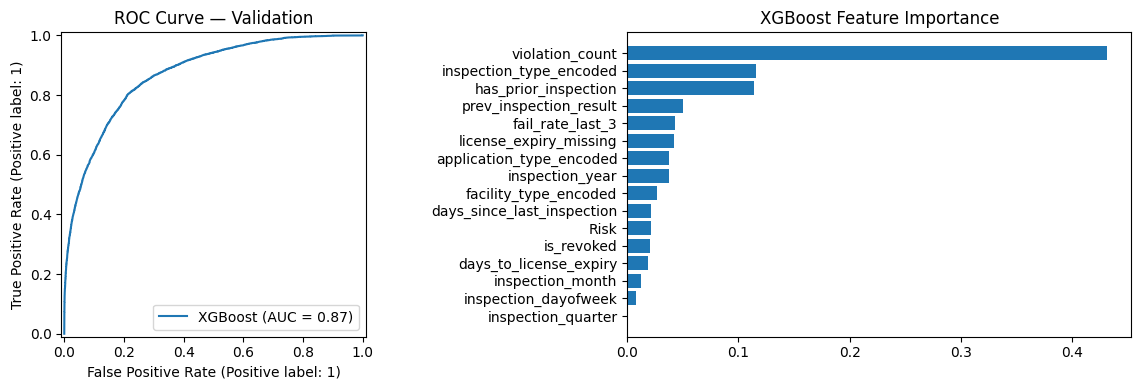

In [7]:
# Compare val ROC curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_val, val_probas, ax=axes[0], name='XGBoost')
axes[0].set_title('ROC Curve — Validation')

# Feature importance — XGBoost
imp_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance')

axes[1].barh(imp_df['feature'], imp_df['importance'])
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.savefig('gradient_boosting_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

In [8]:
summary = pd.DataFrame({
    'Split'              : ['Train', 'Val', 'Test'],
    'Accuracy'           : [train_metrics['accuracy'],            val_metrics['accuracy'],            test_metrics['accuracy']],
    'Balanced Accuracy'  : [train_metrics['balanced_accuracy'],   val_metrics['balanced_accuracy'],   test_metrics['balanced_accuracy']],
    'F1 (weighted)'      : [train_metrics['f1_weighted'],         val_metrics['f1_weighted'],         test_metrics['f1_weighted']],
    'F1 — Fail'          : [train_metrics['f1_fail'],             val_metrics['f1_fail'],             test_metrics['f1_fail']],
    'ROC-AUC'            : [train_metrics['roc_auc'],             val_metrics['roc_auc'],             test_metrics['roc_auc']],
    'PR-AUC'             : [train_metrics['pr_auc'],              val_metrics['pr_auc'],              test_metrics['pr_auc']],
    'MCC'                : [train_metrics['mcc'],                 val_metrics['mcc'],                 test_metrics['mcc']],
    'FNR (missed fails)' : [train_metrics['false_negative_rate'], val_metrics['false_negative_rate'], test_metrics['false_negative_rate']],
    'Catch Rate'         : [train_metrics['sensitivity'],         val_metrics['sensitivity'],         test_metrics['sensitivity']],
}).set_index('Split').round(4)

display(summary)

,Accuracy,Balanced Accuracy,F1 (weighted),F1 — Fail,ROC-AUC,PR-AUC,MCC,FNR (missed fails),Catch Rate
Split,,,,,,,,,
Train,0.7851,0.7953,0.7928,0.6926,0.8835,0.7846,0.5490,0.1799,0.8201
Val,0.7906,0.7945,0.7971,0.6981,0.8718,0.7689,0.5533,0.1958,0.8042
Test,0.8578,0.8583,0.8578,0.8572,0.9293,0.9274,0.7165,0.1224,0.8776


## 9. Confusion Matrix Plots

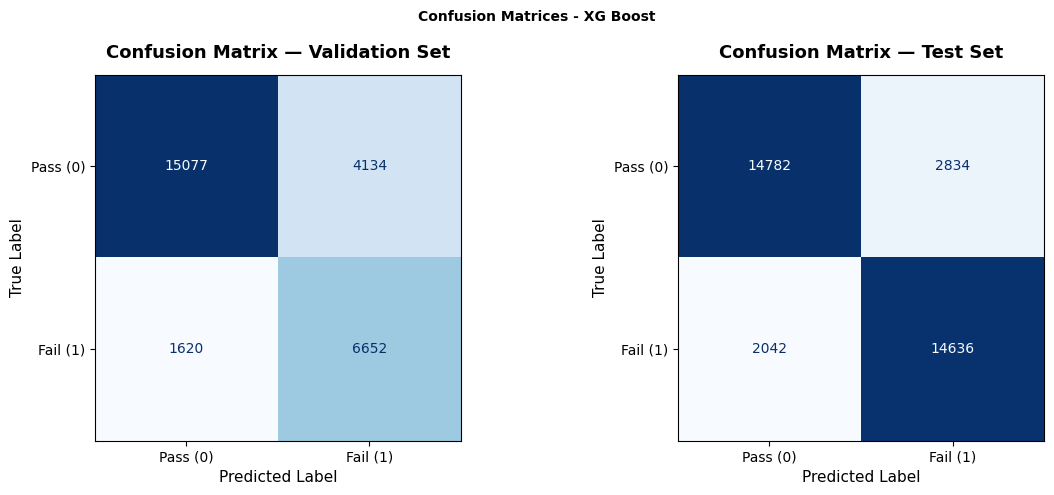

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [val_cm, test_cm],
    ['Validation Set', 'Test Set']
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Pass (0)', 'Fail (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle("Confusion Matrices - XG Boost", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig('confusion_matrices_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Model

In [10]:
models_dir = Path.cwd().parent.parent / 'models'
models_dir.mkdir(exist_ok=True)
joblib.dump(xgb, models_dir / 'gradient_boosting.pkl')
print(f'Model saved to {models_dir / "gradient_boosting.pkl"}')

Model saved to /home/engomar/Desktop/Year_04_Spring_2026/Data_Science/CMPS344_Project/Food-Inspection/models/gradient_boosting.pkl


## 11. MLflow Logging

In [11]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("../../mlruns")
mlflow.set_experiment("food-inspection-classification")

with mlflow.start_run(run_name="xgboost"):

    # --- hyperparameters ---
    mlflow.log_param("n_estimators",     xgb.n_estimators)
    mlflow.log_param("learning_rate",    xgb.learning_rate)
    mlflow.log_param("max_depth",        xgb.max_depth)
    mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 4))
    mlflow.log_param("best_iteration",   xgb.best_iteration)
    mlflow.log_param("random_state",     42)

    # --- standard metrics ---
    mlflow.log_metric("test_accuracy",          test_metrics['accuracy'])
    mlflow.log_metric("test_balanced_accuracy", test_metrics['balanced_accuracy'])
    mlflow.log_metric("test_f1_weighted",       test_metrics['f1_weighted'])
    mlflow.log_metric("test_f1_fail",           test_metrics['f1_fail'])
    mlflow.log_metric("test_f1_pass",           test_metrics['f1_pass'])
    mlflow.log_metric("test_mcc",               test_metrics['mcc'])
    mlflow.log_metric("test_pr_auc",            test_metrics['pr_auc'])
    mlflow.log_metric("test_brier_score",       test_metrics['brier_score'])
    mlflow.log_metric("test_precision_fail",    test_metrics['precision_fail'])
    mlflow.log_metric("test_recall_fail",       test_metrics['recall_fail'])

    # --- business metrics ---
    mlflow.log_metric("test_false_negative_rate", test_metrics['false_negative_rate'])
    mlflow.log_metric("test_false_positive_rate", test_metrics['false_positive_rate'])
    mlflow.log_metric("test_failing_catch_rate",  test_metrics['sensitivity'])

    # --- val + test roc ---
    mlflow.log_metric("val_roc_auc",  val_metrics['roc_auc'])
    mlflow.log_metric("test_roc_auc", test_metrics['roc_auc'])

    # --- model artifact ---
    mlflow.sklearn.log_model(xgb, artifact_path="model")

    # --- plot artifacts ---
    mlflow.log_artifact("gradient_boosting_results.png")
    mlflow.log_artifact("confusion_matrices_xgb.png")

    run_id = mlflow.active_run().info.run_id
    print(f"Run logged. ID: {run_id}")

/home/engomar/.cache/pypoetry/virtualenvs/science-the-data-CK6af-Of-py3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/engomar/.cache/pypoetry/virtualenvs/science-the-data-CK6af-Of-py3.13/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/04 21:54:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 21:54:18 WARNING mlflow.sklearn: Saving scikit-learn models

Run logged. ID: fefcb08be54e4000805f7c5d94424c2d
